In [ ]:
pip install -q torchvision

In [ ]:
import kagglehub
import os
import random
from PIL import Image

In [ ]:
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
path = ".."+path+"/New Plant Diseases Dataset(Augmented)"+"/New Plant Diseases Dataset(Augmented)"
train_path = path+"/train"
val_path = path+"/valid"

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.


Tomato___Leaf_Mold
256
256


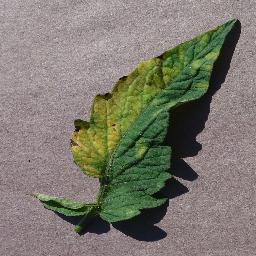

In [ ]:
classes = [name for name in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, name))]
class_name = random.choice(classes)
class_path = os.path.join(train_path, class_name)
img_name = random.choice(os.listdir(class_path))
img_path = os.path.join(class_path, img_name)

img = Image.open(img_path)

print(class_name)
print(img.width)
print(img.height)
img

In [ ]:
import torch
import torch.nn as nn

In [ ]:
s = torch.tensor(10)
s
s.ndim


0

In [ ]:
v = torch.tensor([10,10])
v
v.ndim

1

In [ ]:
m = torch.tensor([[1,2,3],
                  [4,5,6],
                   [7,8,9]])
m.shape

torch.Size([3, 3])

In [ ]:
t = torch.tensor([[[1,2,3],
                  [4,5,6],
                  [7,8,9]]])
t.shape

torch.Size([1, 3, 3])

In [ ]:
s = s.squeeze(dim=0)
s

tensor(10)

In [ ]:
torch.manual_seed(42)
a = torch.randn(3, 3)
a

a.dtype

torch.float32

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [ ]:
weight, bias = 0.7, 0.3

In [ ]:
X = torch.arange(0, 2, 0.02).unsqueeze(dim=1)
y = weight * X + bias
len(X), len(y)

(100, 100)

In [ ]:
train_split = int(0.8*len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

In [ ]:
class SampleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(1, requires_grad = True, dtype=torch.float))
        self.bias = nn.Parameter(torch.randn(1, requires_grad = True, dtype=torch.float))
    def forward(self, x: torch.Tensor):
        return (self.weight * x) + self.bias

In [ ]:
torch.manual_seed(42)
model_first = SampleModel()

In [ ]:
model_first.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model_first.parameters(), lr=0.00001)

In [ ]:
def plot_predictions(X_train, y_train, X_test, y_test, y_preds=None):
    plt.scatter(X_train, y_train, c ="b")
    plt.scatter(X_test, y_test, c = "g")
    if y_preds is not None:
        plt.scatter(X_test, y_preds, c="r")

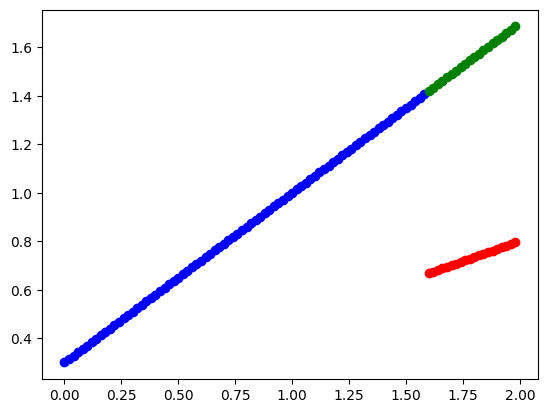

In [ ]:
 with torch.inference_mode():
    y_preds = model_first(X_test)
    plot_predictions(X_train, y_train, X_test, y_test, y_preds)

In [ ]:

torch.manual_seed(42)                  #Trainingloop

epochs = 100

for epoch in range(epochs):
    model_first.train()

    y_pred = model_first(X_train)

    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_first.eval()
    with torch.inference_mode():
        test_pred = model_first(X_test)
        test_loss = loss_fn(test_pred, y_test)

        if epoch % 10 == 0:
            print(f"epoch {epoch} | loss {loss} | test loss {test_loss}")

epoch 0 | loss 0.45333385467529297 | test loss 0.814250111579895
epoch 10 | loss 0.4531714916229248 | test loss 0.8140085935592651
epoch 20 | loss 0.45300912857055664 | test loss 0.8137673139572144
epoch 30 | loss 0.4528467655181885 | test loss 0.8135259747505188
epoch 40 | loss 0.45268434286117554 | test loss 0.813284695148468
epoch 50 | loss 0.4525219798088074 | test loss 0.8130432367324829
epoch 60 | loss 0.4523595869541168 | test loss 0.8128019571304321
epoch 70 | loss 0.45219722390174866 | test loss 0.8125605583190918
epoch 80 | loss 0.4520348608493805 | test loss 0.812319278717041
epoch 90 | loss 0.45187243819236755 | test loss 0.8120778799057007


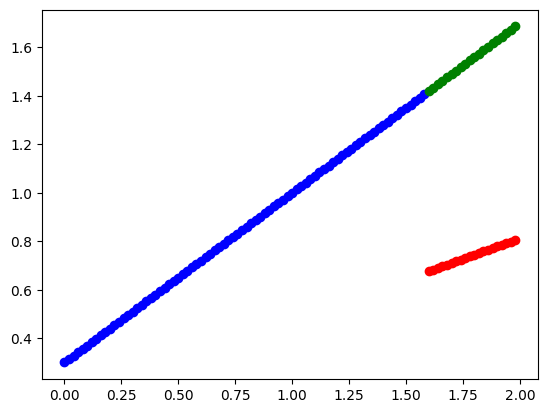

In [ ]:
with torch.inference_mode():
    y_preds = model_first(X_test)
    plot_predictions(X_train, y_train, X_test, y_test, y_preds)

In [ ]:
model_first.state_dict()

OrderedDict([('weight', tensor([0.3398])), ('bias', tensor([0.1328]))])

In [ ]:
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

In [ ]:
data_transformer = transforms.Compose([
      transforms.ToTensor(),
          transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
          ])

In [ ]:
train_dataset = datasets.ImageFolder(root = train_path, transform=None)

In [ ]:
import kagglehub
import os
from torchvision import datasets, transforms

# Define path and val_path (from previous cells for self-containment)
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
path = ".."+path+"/New Plant Diseases Dataset(Augmented)"+"/New Plant Diseases Dataset(Augmented)"
val_path = path+"/valid"

# Define data_transformer (from previous cell for self-containment)
data_transformer = transforms.Compose([
      transforms.ToTensor(),
          transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]) # Using placeholder mean and std, replace with actual values
          ])

valid_dataset = datasets.ImageFolder(root = val_path, transform=data_transformer)

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.


In [ ]:
len(train_dataset), len(valid_dataset)

(70295, 17572)

In [ ]:
transformed_img = data_transformer(img)
print(transformed_img)

tensor([[[0.4588, 0.4118, 0.4902,  ..., 0.5216, 0.5059, 0.4902],
         [0.4902, 0.4745, 0.5059,  ..., 0.5216, 0.5216, 0.5137],
         [0.4980, 0.5216, 0.4902,  ..., 0.4980, 0.5137, 0.5216],
         ...,
         [0.2941, 0.3412, 0.3569,  ..., 0.2863, 0.2863, 0.3412],
         [0.2314, 0.2941, 0.3412,  ..., 0.3255, 0.3647, 0.3020],
         [0.2863, 0.3333, 0.3569,  ..., 0.3176, 0.4039, 0.2941]],

        [[0.3804, 0.3333, 0.4118,  ..., 0.4431, 0.4275, 0.4118],
         [0.4118, 0.3961, 0.4275,  ..., 0.4431, 0.4431, 0.4353],
         [0.4196, 0.4431, 0.4118,  ..., 0.4196, 0.4353, 0.4431],
         ...,
         [0.1843, 0.2314, 0.2471,  ..., 0.1922, 0.1922, 0.2471],
         [0.1216, 0.1843, 0.2314,  ..., 0.2314, 0.2706, 0.2078],
         [0.1765, 0.2235, 0.2471,  ..., 0.2235, 0.3098, 0.2000]],

        [[0.3882, 0.3412, 0.4196,  ..., 0.4510, 0.4353, 0.4196],
         [0.4196, 0.4039, 0.4353,  ..., 0.4510, 0.4510, 0.4431],
         [0.4275, 0.4510, 0.4196,  ..., 0.4275, 0.4431, 0.

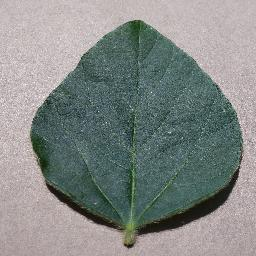

In [ ]:
img

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle = True, num_workers=2)

In [ ]:
valid_loader = DataLoader(valid_dataset, batch_size = 32, shuffle = False, num_workers = 2)

In [ ]:
len(train_loader), len(valid_loader)

(2197, 550)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
from torchvision import transforms

dummy_transform = transforms.Compose([
      transforms.Resize((224, 224)),
          transforms.ToTensor()
          ])

In [ ]:
from torchvision import datasets

train_dataset = datasets.ImageFolder(root = train_path, transform=dummy_transform)

NameError: name 'train_path' is not defined

In [ ]:
def compute_mean_std(dataset, batch_size=16, num_workers=2):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle = False, num_workers=2)
    channel_sum = torch.zeros(3, device=device)
    channel_sqsum = torch.zeros(3, device=device)
    pixel_count = 0

    for x, _ in loader:
        x = x.to(device)
        b, c, h, w = x.shape
        pixel_count+= h * w * b
        channel_sum += x.sum(dim=[0, 2, 3])
        channel_sqsum += (x**2).sum(dim=[0, 2, 3])

    mean = channel_sum / pixel_count
    std = torch.sqrt(channel_sqsum/ pixel_count - mean ** 2)
    return  mean, std

In [ ]:
mean = [0.47596338391304016, 0.5003822445869446, 0.42664194107055664]
std = [0.21028108894824982, 0.18884526193141937, 0.22626696527004242]

In [ ]:
train_transform = transforms.Compose([
      transforms.Resize((224,224)),
          transforms.RandomHorizontalFlip(0.5),
              transforms.ToTensor(),
                  transforms.Normalize(mean=mean, std=std)
                  ])

In [ ]:
test_transform = transforms.Compose([
      transforms.Resize((224,224)),
          transforms.ToTensor(),
              transforms.Normalize(mean=mean, std=std)
              ])

In [ ]:
train_dataset = datasets.ImageFolder(root = train_path, transform=train_transform)

In [ ]:
test_dataset = datasets.ImageFolder(root = train_path, transform=test_transform)

In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle = True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle = False, num_workers=2)

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, in_features, out_features, hidden_units):
        super().__init__()
        self.layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=in_features, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=out_features)
        )

    def forward(self, x):
        return self.layer(x)

In [ ]:
model = SimpleCNN(3*224*224, 38, 256)
model.to(device)

SimpleCNN(
  (layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=150528, out_features=256, bias=True)
    (2): Linear(in_features=256, out_features=38, bias=True)
  )
)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

In [ ]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=381):
        super(SimpleCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Calculate the output size of the convolutional layers
        # This requires a dummy forward pass
        with torch.no_grad():
            dummy_input = torch.randn(1, 3, 224, 224) # Assuming input image size is 224x224 based on transforms
            dummy_output = self.conv_layers(dummy_input)
            flattened_size = dummy_output.view(dummy_output.size(0), -1).size(1)


        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_size, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

device = 'cuda' if torch.cuda.is_available() else 'cpu'
# Instantiate the model with the correct number of classes
model = SimpleCNN(num_classes=38).to(device)

In [ ]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
from torchvision import datasets, transforms
import kagglehub
import torch.nn as nn

# ---------------------------
# 1. Define Loss & Optimizer
# ---------------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)



In [ ]:
import kagglehub
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Define data paths and transforms (from previous cells for self-containment)
path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")
path = ".."+path+"/New Plant Diseases Dataset(Augmented)"+"/New Plant Diseases Dataset(Augmented)"
train_path = path+"/train"
val_path = path+"/valid"

mean = [0.47596338391304016, 0.5003822445869446, 0.42664194107055664]
std = [0.21028108894824982, 0.18884526193141937, 0.22626696527004242]

train_transform = transforms.Compose([
      transforms.Resize((224,224)),
          transforms.RandomHorizontalFlip(0.5),
              transforms.ToTensor(),
                  transforms.Normalize(mean=mean, std=std)
                  ])

test_transform = transforms.Compose([
      transforms.Resize((224,224)),
          transforms.ToTensor(),
              transforms.Normalize(mean=mean, std=std)
              ])

train_dataset = datasets.ImageFolder(root = train_path, transform=train_transform)
test_dataset = datasets.ImageFolder(root = train_path, transform=test_transform) # Using train_path for test dataset as well

# Define DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle = True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle = False, num_workers=2)

# Define device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Instantiate the model with the correct number of classes (assuming 38 based on previous cells)
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=38):
        super(SimpleCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Calculate the output size of the convolutional layers
        # This requires a dummy forward pass
        with torch.no_grad():
            dummy_input = torch.randn(1, 3, 224, 224) # Assuming input image size is 224x224 based on transforms
            dummy_output = self.conv_layers(dummy_input)
            flattened_size = dummy_output.view(dummy_output.size(0), -1).size(1)


        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_size, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

model = SimpleCNN(num_classes=38).to(device)


# Define Loss & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


# Training Loop
epochs = 5
for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}")

    # Evaluation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Test Accuracy: {100 * correct / total:.2f}%")

Using Colab cache for faster access to the 'new-plant-diseases-dataset' dataset.


In [ ]:
from datasets import load_dataset

ds = load_dataset("nyu-mll/glue", "ax")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

ax/test-00000-of-00001.parquet:   0%|          | 0.00/80.8k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/1104 [00:00<?, ? examples/s]

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import os

from tensorflow import keras
from tensorflow.keras.preprocessing import image

from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
    path = '/content/' + fn
    img = image.load_img(path, target_size=(224, 224))  # Resize image
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)

    # Preprocess input
    x = tf.keras.applications.mobilenet_v2.preprocess_input(x)


    model = tf.keras.applications.MobileNetV2(weights='imagenet')

    preds = model.predict(x)

    # Decode predictions
    print('Top 5 predictions:')
    top_preds = tf.keras.applications.mobilenet_v2.decode_predictions(preds, top=5)[0]
    for i, p in enumerate(top_preds):
        print(f"{i+1}. {p[1]} ({p[2]*100:.2f}%)")

In [ ]:
import pandas as pd

df = pd.read_parquet("hf://datasets/ButterChicken98/plantvillage-image-text-pairs/data/train-00000-of-00001.parquet")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
df.head()

,image,caption,captions
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Tomato healthy,[A vibrant green and healthy tomato leaf with ...
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Tomato Late blight,[A tomato leaf showing dark brown lesions and ...
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Tomato healthy,[A vibrant green and healthy tomato leaf with ...
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Tomato mosaic virus,[A tomato leaf with mosaic-like patterns of li...
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Pepper bell healthy,"[A fresh green bell pepper leaf with a smooth,..."


In [ ]:
df = df.drop(columns=["image"])
print(df.head())
print(df.shape)

               caption                                           captions
0       Tomato healthy  [A vibrant green and healthy tomato leaf with ...
1   Tomato Late blight  [A tomato leaf showing dark brown lesions and ...
2       Tomato healthy  [A vibrant green and healthy tomato leaf with ...
3  Tomato mosaic virus  [A tomato leaf with mosaic-like patterns of li...
4  Pepper bell healthy  [A fresh green bell pepper leaf with a smooth,...
(20638, 2)


In [ ]:
df = df.explode("captions")
print(df.head())
print(df.shape)

              caption                                           captions
0      Tomato healthy  A vibrant green and healthy tomato leaf with s...
0      Tomato healthy  A healthy Solanum lycopersicum leaf, free of d...
0      Tomato healthy  A fresh tomato leaf outdoors, glowing in sunli...
0      Tomato healthy  A clean and healthy tomato leaf image, perfect...
1  Tomato Late blight  A tomato leaf showing dark brown lesions and w...
(82552, 2)


In [ ]:
caption = df["caption"].unique().tolist()
caption, len(caption)

(['Tomato healthy',
  'Tomato Late blight',
  'Tomato mosaic virus',
  'Pepper bell healthy',
  'Potato Early blight',
  'Tomato Early blight',
  'Tomato YellowLeaf Curl Virus',
  'Tomato Target Spot',
  'Pepper bell Bacterial spot',
  'Tomato Septoria leaf spot',
  'Tomato Spider mites Two spotted spider mite',
  'Tomato Bacterial spot',
  'Potato Late blight',
  'Tomato Leaf Mold',
  'Potato healthy'],
 15)

In [ ]:
df.to_csv("dataset.csv", index=False)

In [ ]:
df = pd.read_csv("dataset.csv")

In [ ]:
df.head()

,caption,captions
0,Tomato healthy,A vibrant green and healthy tomato leaf with s...
1,Tomato healthy,"A healthy Solanum lycopersicum leaf, free of d..."
2,Tomato healthy,"A fresh tomato leaf outdoors, glowing in sunli..."
3,Tomato healthy,"A clean and healthy tomato leaf image, perfect..."
4,Tomato Late blight,A tomato leaf showing dark brown lesions and w...


In [ ]:
num_labels = 15
data_col_name = "captions"
label_col_name = "caption"

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
encoder = LabelEncoder()
encoder.fit(df[label_col_name].tolist())
df["label"] = encoder.transform(df[label_col_name].tolist())

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
df_train, df_test = train_test_split(df, train_size=0.8)

In [ ]:
from datasets import Dataset

In [ ]:
train_dataset = Dataset.from_pandas(df_train)
test_dataset = Dataset.from_pandas(df_test)

In [ ]:
model_name = "distilbert-base-uncased"

In [ ]:
from transformers import AutoTokenizer

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
def tokenize_fn(data):
    return tokenizer(data["captions"], truncation=True)

In [ ]:
tokenized_train = train_dataset.map(tokenize_fn, batched=True)
tokenized_test = test_dataset.map(tokenize_fn, batched=True)

Map:   0%|          | 0/66041 [00:00<?, ? examples/s]

Map:   0%|          | 0/16511 [00:00<?, ? examples/s]

In [ ]:
from transformers import DataCollatorWithPadding

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
from transformers import AutoModelForSequenceClassification

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels= 15)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00


In [ ]:
import evaluate
from transformers import TrainingArguments, Trainer
import numpy as np

In [ ]:
eval_metrics = evaluate.load("accuracy")

In [ ]:
def metrics(eval_pred):
    logits, labels = eval_pred
    prediction = np.argmax(logits, axis=1)
    return eval_metrics.compute(predictions=prediction, references=labels)

In [ ]:
training_arguments = TrainingArguments(
      output_dir="./checkpoints",
      per_device_train_batch_size=8,
      per_device_eval_batch_size=8,
          num_train_epochs=2,
          learning_rate=0.00005,
          save_strategy="epoch",
          logging_strategy="epoch",
          save_total_limit=2,
           weight_decay=0.01,
       report_to="none"

)

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels= num_labels)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
import evaluate
import numpy as np

eval_metrics = evaluate.load("accuracy")

def metrics(eval_pred):
    logits, labels = eval_pred
    prediction = np.argmax(logits, axis=1)
    return eval_metrics.compute(predictions=prediction, references=labels)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_arguments,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=metrics,
)

trainer.train()

/tmp/ipython-input-1507872726.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
8256,0.022500
16512,0.000000


TrainOutput(global_step=16512, training_loss=0.01126898348435458, metrics={'train_runtime': 666.7556, 'train_samples_per_second': 198.097, 'train_steps_per_second': 24.765, 'total_flos': 922745559316230.0, 'train_loss': 0.01126898348435458, 'epoch': 2.0})

In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.2 MB/s eta 0:00:00


In [ ]:
import evaluate
import numpy as np

eval_metrics = evaluate.load("accuracy")

def metrics(eval_pred):
    logits, labels = eval_pred
    prediction = np.argmax(logits, axis=1)
    return eval_metrics.compute(predictions=prediction, references=labels)

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_arguments,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=metrics,
)

trainer.train()

/tmp/ipython-input-1507872726.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
8256,0.021400
16512,0.000000


TrainOutput(global_step=16512, training_loss=0.010689136835639528, metrics={'train_runtime': 681.1956, 'train_samples_per_second': 193.897, 'train_steps_per_second': 24.24, 'total_flos': 921961957215870.0, 'train_loss': 0.010689136835639528, 'epoch': 2.0})

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
def tokenize_fn(data):
    return tokenizer(data["captions"], truncation=True)

tokenized_train = train_dataset.map(tokenize_fn, batched=True)
tokenized_test = test_dataset.map(tokenize_fn, batched=True)

Map:   0%|          | 0/66041 [00:00<?, ? examples/s]

Map:   0%|          | 0/16511 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, train_size=0.8)

In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(df_train)
test_dataset = Dataset.from_pandas(df_test)

In [ ]:
import pandas as pd

df = pd.read_parquet("hf://datasets/ButterChicken98/plantvillage-image-text-pairs/data/train-00000-of-00001.parquet")
df = df.drop(columns=["image"])
df = df.explode("captions")

from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
encoder.fit(df["caption"].tolist())
df["label"] = encoder.transform(df["caption"].tolist())

In [ ]:
from transformers import TrainingArguments

training_arguments = TrainingArguments(
    output_dir="./checkpoints",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,
    learning_rate=0.00005,
    save_strategy="epoch",
    logging_strategy="epoch",
    save_total_limit=2,
    weight_decay=0.01,
    report_to="none"
)

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels= num_labels)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
num_labels = 15

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels= num_labels)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
model_name = "distilbert-base-uncased"

In [ ]:
trainer = Trainer(
      model=model,
       args=training_arguments,
       train_dataset=tokenized_train,
       eval_dataset=tokenized_test,
       tokenizer=tokenizer,
       data_collator=data_collator,
       compute_metrics= metrics
                              )

/tmp/ipython-input-1641493280.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [ ]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer, TrainingArguments, DataCollatorWithPadding
from datasets import Dataset
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import evaluate
import numpy as np

# Load and preprocess data
df = pd.read_parquet("hf://datasets/ButterChicken98/plantvillage-image-text-pairs/data/train-00000-of-00001.parquet")
df = df.drop(columns=["image"])
df = df.explode("captions")

# Encode labels
encoder = LabelEncoder()
encoder.fit(df["caption"].tolist())
df["label"] = encoder.transform(df["caption"].tolist())

# Split data
df_train, df_test = train_test_split(df, train_size=0.8)

# Create datasets
train_dataset = Dataset.from_pandas(df_train)
test_dataset = Dataset.from_pandas(df_test)

model_name = "distilbert-base-uncased"
num_labels = 15

# Define model
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

# Define training arguments
training_arguments = TrainingArguments(
      output_dir="./checkpoints",
          per_device_train_batch_size=8,
          per_device_eval_batch_size=8,
          num_train_epochs=2,
          learning_rate=0.00005,
          save_strategy="epoch",
          logging_strategy="epoch",
          save_total_limit=2,
          weight_decay=0.01,
          report_to="none"

)

# Define tokenizer and tokenize datasets
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_fn(data):
    return tokenizer(data["captions"], truncation=True)

tokenized_train = train_dataset.map(tokenize_fn, batched=True)
tokenized_test = test_dataset.map(tokenize_fn, batched=True)

# Define metrics
eval_metrics = evaluate.load("accuracy")

def metrics(eval_pred):
    logits, labels = eval_pred
    prediction = np.argmax(logits, axis=1)
    return eval_metrics.compute(predictions=prediction, references=labels)

# Define data collator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/66041 [00:00<?, ? examples/s]

Map:   0%|          | 0/16511 [00:00<?, ? examples/s]

In [ ]:
from transformers import AutoModelForSequenceClassification

model_name = "distilbert-base-uncased"
num_labels = 15

model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
